In [1]:
import time
import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Preprocesado de datos

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., None]
x_test = x_test[..., None]

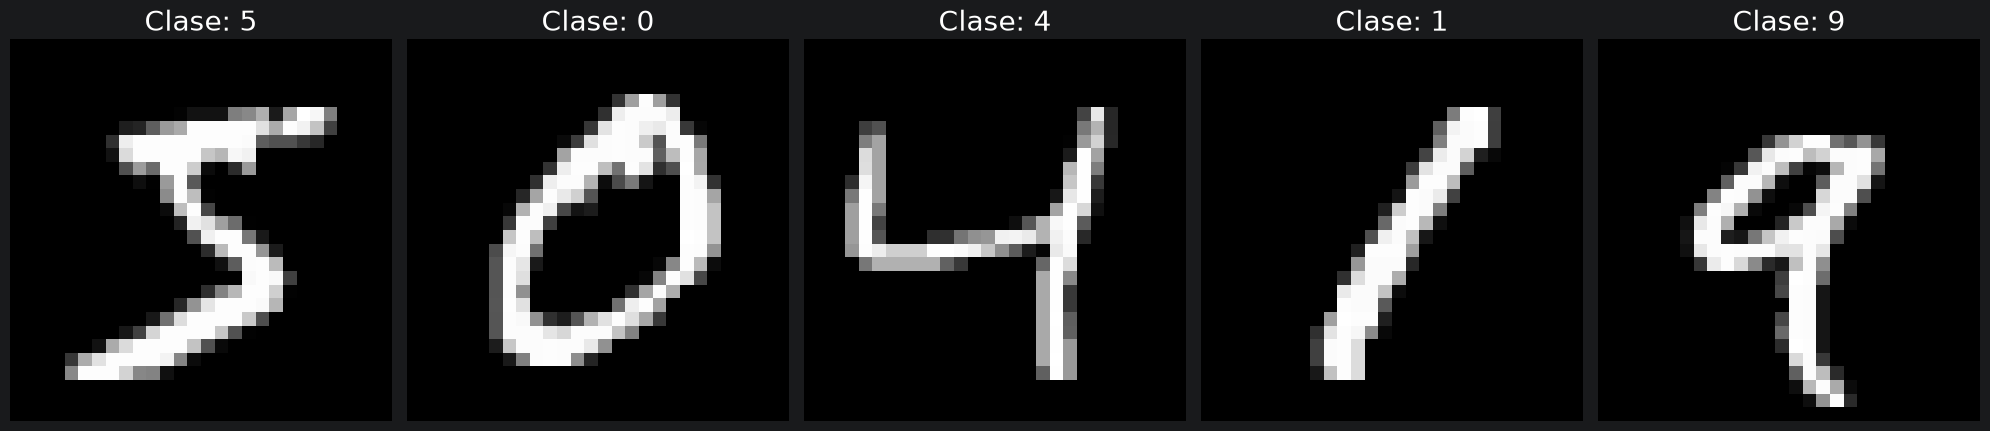

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(x_train[:5]):
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Clase: {y_train[i]}", size=20)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Funciones auxiliares

In [4]:
def entrenar_evaluar(model, x_tr, y_tr, x_te, y_te, epochs=6):
    t_ini = time.time() # calculamos el tiempo exacto del entrenamiento
    h = model.fit(x_tr, y_tr, epochs=epochs, batch_size=128, validation_split=0.15)
    t_total = time.time() - t_ini

    prob_tr = model.predict(x_tr, batch_size=128) # obtenemos las salidas del modelo (una probabilidad)
    prob_te = model.predict(x_te, batch_size=128)
    pred_tr = np.argmax(prob_tr, axis=1) # la predicccion es la salida con mayor probabilidad
    pred_te = np.argmax(prob_te, axis=1)

    acc_tr = accuracy_score(y_tr, pred_tr) # calculamos el accuracy
    acc_te = accuracy_score(y_te, pred_te)

    num_err_tr = int(np.sum(pred_tr.ravel() != y_tr))
    num_err_te = int(np.sum(pred_te.ravel() != y_te))

    prec_te = precision_score(y_te, pred_te, average="macro")
    rec_te = recall_score(y_te, pred_te, average="macro")
    f1_te = f1_score(y_te, pred_te, average="macro")
    auc_te = roc_auc_score(y_te, prob_te, multi_class="ovr")

    cm_tr = confusion_matrix(y_tr, pred_tr) # creamos las matrices de confusion
    cm_te = confusion_matrix(y_te, pred_te)

    metricas = {
        "tiempo_entrenamiento(s)": round(t_total, 2),
        "train_accuracy": round(acc_tr, 4),
        "test_accuracy": round(acc_te, 4),
        "errores_train": f"{num_err_tr}/{len(y_tr)}",
        "errores_test": f"{num_err_te}/{len(y_te)}",
        "precision": round(prec_te, 4),
        "recall": round(rec_te, 4),
        "f1_score": round(f1_te, 4),
        "auc_roc": round(auc_te, 4),
    }

    return metricas, model, cm_tr, cm_te, pred_te, h

def resumen(cm_tr, cm_te, h):
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    clases = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"  ]

    axes[0, 0].set_title("train cofusion matrix")
    disp_tr = ConfusionMatrixDisplay(cm_tr, display_labels=clases)
    disp_tr.plot(ax=axes[0, 0])

    axes[0, 1].set_title("test confusion matrix")
    disp_te = ConfusionMatrixDisplay(cm_te, display_labels=clases)
    disp_te.plot(ax=axes[0, 1])

    axes[1, 0].plot(h.history["loss"], label="loss", color="b")
    axes[1, 0].plot(h.history["val_loss"], label="validation_loss", color="orange")
    axes[1, 0].set_title("loss curves")
    axes[1, 0].set_xlabel("epochs")
    axes[1, 0].set_ylabel("loss")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(h.history["accuracy"], label="train_accuracy", color="green")
    axes[1, 1].plot(h.history["val_accuracy"], label="validation_accuracy", color="yellow")
    axes[1, 1].set_title("accuracy curves")
    axes[1, 1].set_xlabel("epochs")
    axes[1, 1].set_ylabel("accuracy")
    axes[1, 1].set_ylim(0.8, 1.0)
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.show()

In [5]:
metricas = pd.DataFrame()

## Desarrollo de modelos

Para cada experimento dejaremos fijos los valores de épocas (6), optimizador (Adam), tamaño de lote (128) y tasa de aprendizaje (0.001). Además hemos incluido un conjunto de validación para ir comprobando como avanza el entrenamiento. Usaremos un 15% del conjunto de entrenamiento como conjunto de validación.

### Experimento 0

Vamos a crear la CNN más básica con 1 capa convolucional (32 kernels de 3x3), 1 capa MaxPooling2D (2x2), un aplanado (flatten) y 1 capa densa de 128 neuronas antes de la salida de 10 clases. Este será nuestro baseline y veremos si los cambios de los siguientes experimentos mejoran o empeoran el modelo.


Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9299 - loss: 0.2492 - val_accuracy: 0.9751 - val_loss: 0.0885
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9777 - loss: 0.0762 - val_accuracy: 0.9806 - val_loss: 0.0655
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9851 - loss: 0.0515 - val_accuracy: 0.9821 - val_loss: 0.0591
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9887 - loss: 0.0381 - val_accuracy: 0.9826 - val_loss: 0.0573
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9920 - loss: 0.0283 - val_accuracy: 0.9836 - val_loss: 0.0581
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9943 - loss: 0.0211 - val_accuracy: 0.9844 - val_loss: 0.0606
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998


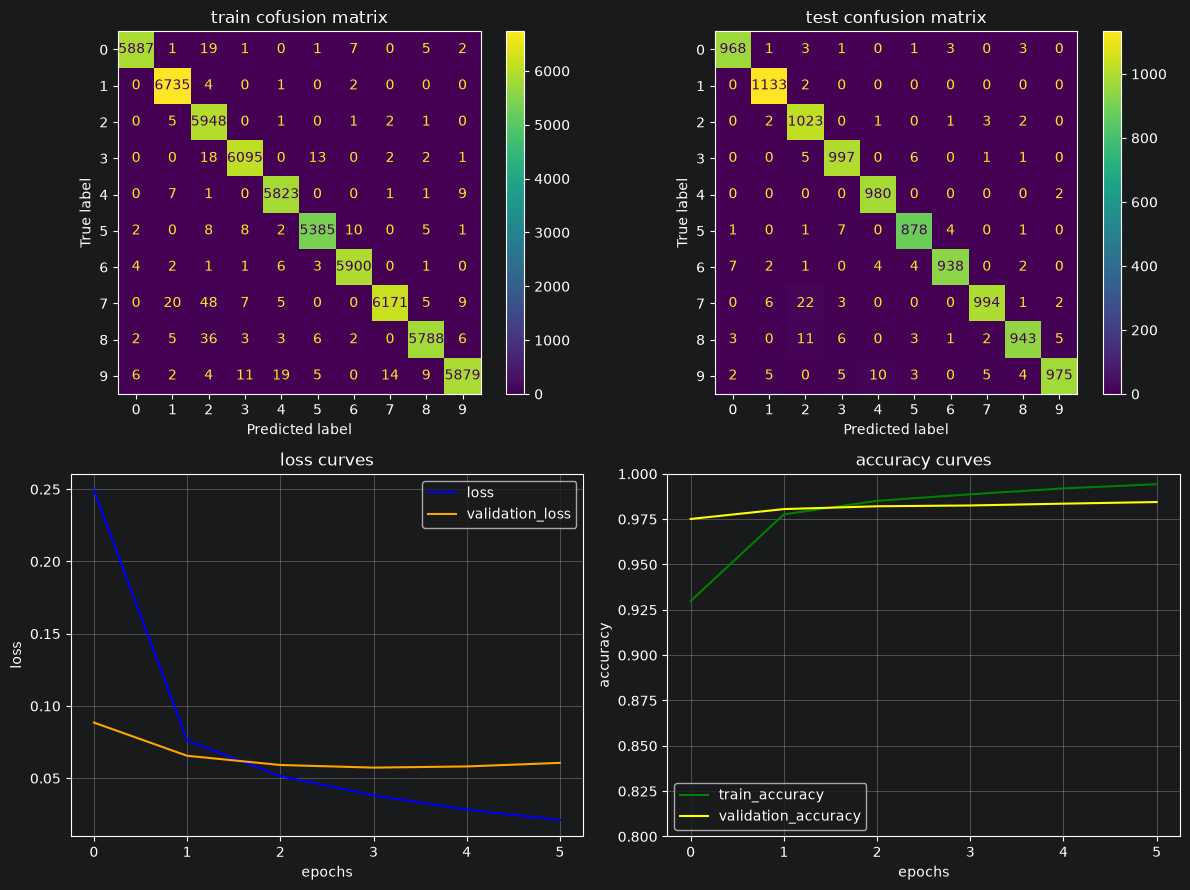

In [6]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met0, mod0, cm_tr0, cm_te0, pred_te0, h0 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met0])], ignore_index=True)
display(metricas)
resumen(cm_tr0, cm_te0, h0)

De primeras obtenemos un 98.29% de accuracy. Podemos ver que las curvas de error son suaves y no hay demasiado overfitting. Ahora mismo este baseline es peor que el mejor modelo de la Práctica 2, asi que veremos si podemos mejorarlo mucho más.

## Experimento 1
En este experimento vamos a comprobar si cambiar la forma de hacer el pooling empeora o mejora el modelo. En vez de hacer MaxPoolig, usaremos la media, AveragePooling. Todos los demas parámetros siguen igual.

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9197 - loss: 0.2908 - val_accuracy: 0.9680 - val_loss: 0.1135
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9729 - loss: 0.0920 - val_accuracy: 0.9791 - val_loss: 0.0753
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9822 - loss: 0.0605 - val_accuracy: 0.9819 - val_loss: 0.0647
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9869 - loss: 0.0456 - val_accuracy: 0.9837 - val_loss: 0.0599
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9896 - loss: 0.0355 - val_accuracy: 0.9840 - val_loss: 0.0579
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9924 - loss: 0.0281 - val_accuracy: 0.9840 - val_loss: 0.0590
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998
1,27.47,0.9927,0.9854,436/60000,146/10000,0.9854,0.9853,0.9853,0.9998


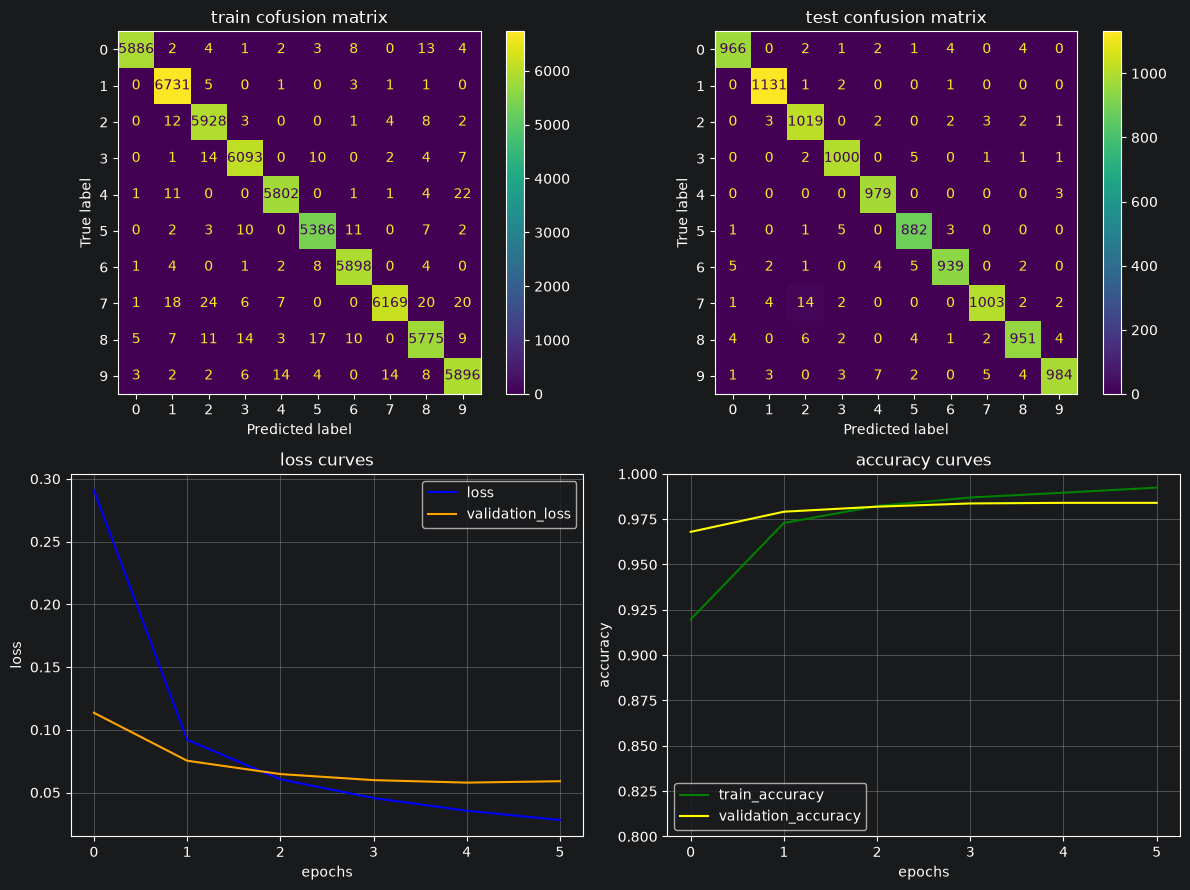

In [7]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.AveragePooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met1, mod1, cm_tr1, cm_te1, pred_te1, h1 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met1])], ignore_index=True)
display(metricas)
resumen(cm_tr1, cm_te1, h1)

Podemos ver que ha mejorado un poco los resultados. Obtenemos un 98.54% de accuracy y un total de 146 errores, a diferencia de los 171 del baseline. Parece ser que para este dataset funciona mejor.

## Experimento 2
En este experimento aumentamos el tamaño del kernel de 3x3 a 5x5 para ampliar el campo receptivo inicial. La idea es comprobar si capturar una región de píxeles más amplio mejora o  perjudica los resultados.

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9381 - loss: 0.2185 - val_accuracy: 0.9776 - val_loss: 0.0774
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9804 - loss: 0.0649 - val_accuracy: 0.9827 - val_loss: 0.0573
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9869 - loss: 0.0439 - val_accuracy: 0.9862 - val_loss: 0.0500
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9905 - loss: 0.0318 - val_accuracy: 0.9850 - val_loss: 0.0494
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9934 - loss: 0.0237 - val_accuracy: 0.9852 - val_loss: 0.0521
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9948 - loss: 0.0182 - val_accuracy: 0.9868 - val_loss: 0.0528
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step  
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998
1,27.47,0.9927,0.9854,436/60000,146/10000,0.9854,0.9853,0.9853,0.9998
2,24.55,0.9940,0.9876,360/60000,124/10000,0.9876,0.9875,0.9875,0.9998


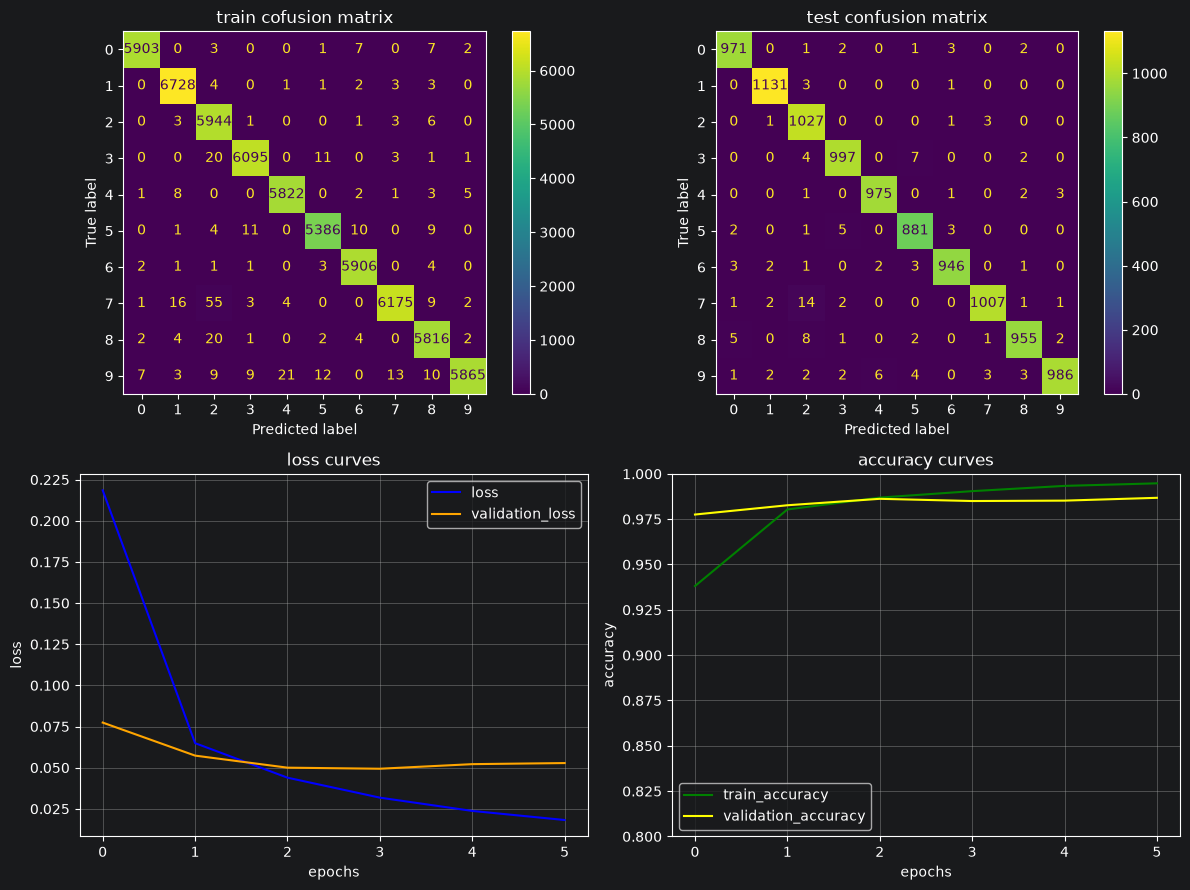

In [8]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (5, 5), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met2, mod2, cm_tr2, cm_te2, pred_te2, h2 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met2])], ignore_index=True)
display(metricas)
resumen(cm_tr2, cm_te2, h2)

Volvemos a mejorar el modelo, esta vez subimos a 98.76% de accuracy y bajamos a 124 errores. Como tenemos un kernel más grande, permite ver más rasgos del número en un mismo paso (como bordes y curvas).

## Experimento 3
En este experimento configuramos strides=2 para que el kernel avance de dos en dos píxeles durante la convolución. Al dar menos pasos sobre la imagen, reducimos su dimensión directamente en la propia capa convolucional sin usar una capa de pooling.

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9162 - loss: 0.2996 - val_accuracy: 0.9658 - val_loss: 0.1215
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9715 - loss: 0.0971 - val_accuracy: 0.9770 - val_loss: 0.0813
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9820 - loss: 0.0606 - val_accuracy: 0.9786 - val_loss: 0.0703
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9880 - loss: 0.0423 - val_accuracy: 0.9802 - val_loss: 0.0663
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9919 - loss: 0.0296 - val_accuracy: 0.9810 - val_loss: 0.0645
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9944 - loss: 0.0213 - val_accuracy: 0.9818 - val_loss: 0.0659
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998
1,27.47,0.9927,0.9854,436/60000,146/10000,0.9854,0.9853,0.9853,0.9998
2,24.55,0.9940,0.9876,360/60000,124/10000,0.9876,0.9875,0.9875,0.9998
3,15.42,0.9941,0.9821,354/60000,179/10000,0.9821,0.9820,0.9820,0.9998


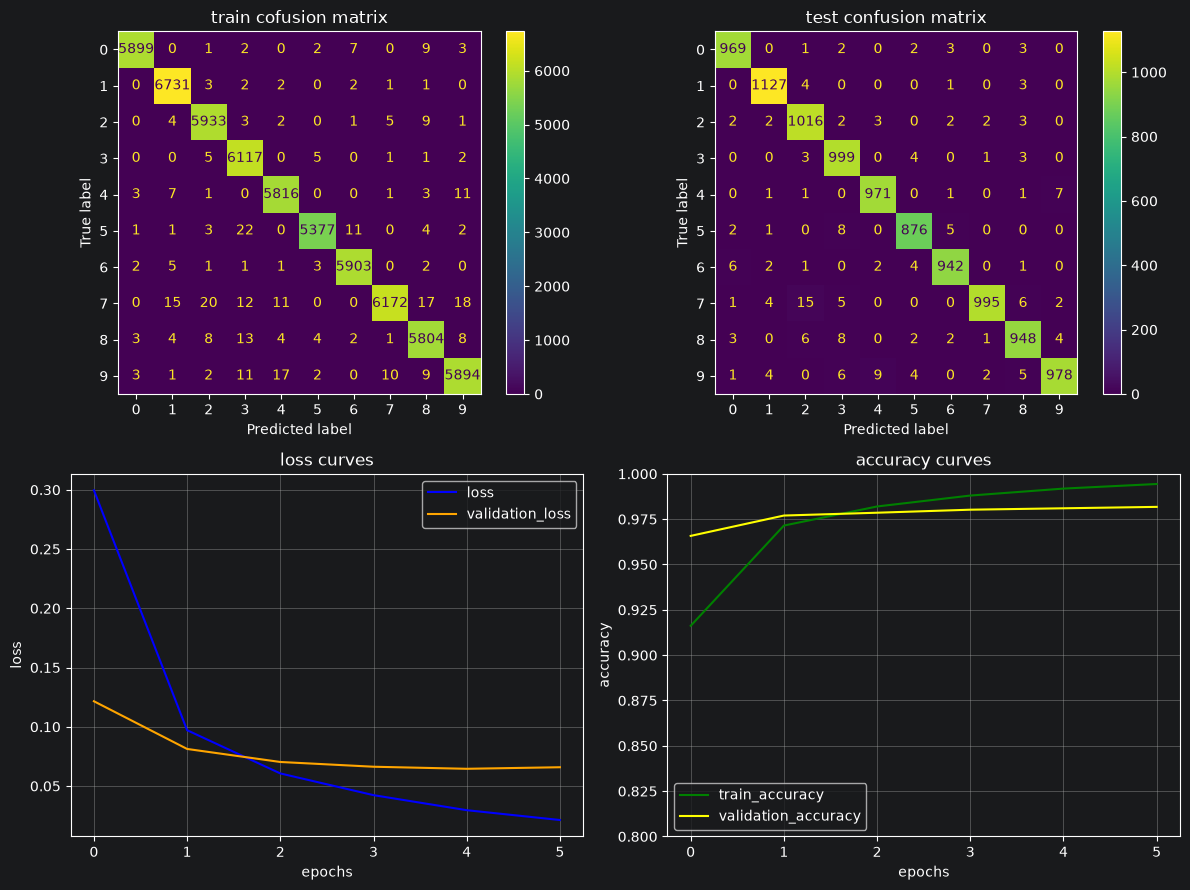

In [9]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), strides=2, activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met3, mod3, cm_tr3, cm_te3, pred_te3, h3 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met3])], ignore_index=True)
display(metricas)
resumen(cm_tr3, cm_te3, h3)

Podemos ver que el rendimiento del modelo ha empeorado, bajando a un 98.21% de accuracy y 179 errores en test. Esto se debe a que, al dar saltos más grandes (strides=2), la capa ignora parte de los píxeles y pierde información de la imagen antes de haber podido extraer características suficientes.

## Experimento 4

En este experimento añadimos BatchNormalization() justo después de la convolución y un Dropout(0.5) tras el max pooling. La idea es estabilizar el aprendizaje normalizando las activaciones de la red y, a la vez, desactivar aleatoriamente la mitad de las neuronas para evitar el overfitting y obligar al modelo a aprender mejor.

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9375 - loss: 0.2071 - val_accuracy: 0.9706 - val_loss: 0.3084
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9766 - loss: 0.0730 - val_accuracy: 0.9832 - val_loss: 0.0559
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9829 - loss: 0.0520 - val_accuracy: 0.9830 - val_loss: 0.0563
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9874 - loss: 0.0380 - val_accuracy: 0.9873 - val_loss: 0.0459
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.9894 - loss: 0.0311 - val_accuracy: 0.9859 - val_loss: 0.0533
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 0.9843 - val_loss: 0.0613
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998
1,27.47,0.9927,0.9854,436/60000,146/10000,0.9854,0.9853,0.9853,0.9998
2,24.55,0.9940,0.9876,360/60000,124/10000,0.9876,0.9875,0.9875,0.9998
3,15.42,0.9941,0.9821,354/60000,179/10000,0.9821,0.9820,0.9820,0.9998
4,71.73,0.9945,0.9838,332/60000,162/10000,0.9839,0.9836,0.9837,0.9998


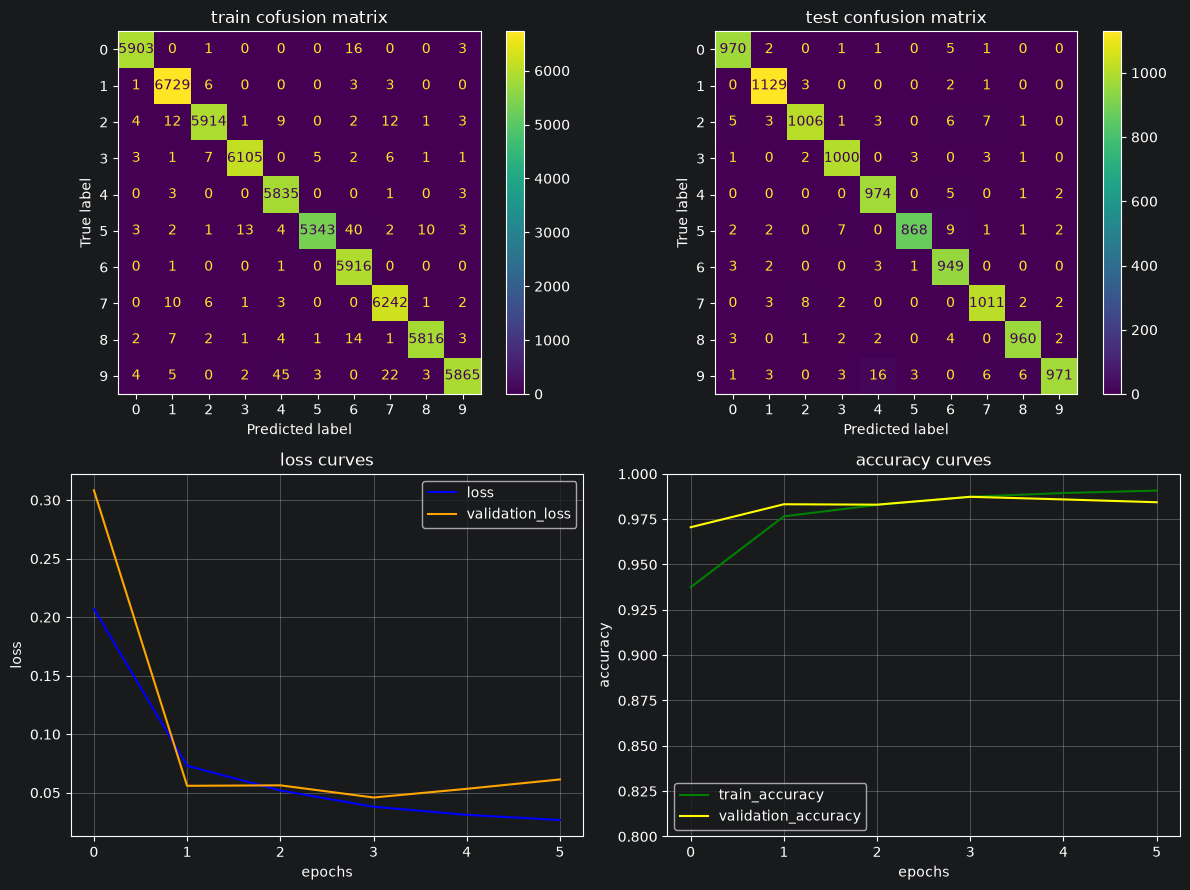

In [10]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met4, mod4, cm_tr4, cm_te4, pred_te4, h4 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
)

metricas = pd.concat([metricas, pd.DataFrame([met4])], ignore_index=True)
display(metricas)
resumen(cm_tr4, cm_te4, h4)

Al añadir estas capas hemos obtenido un 98.38% de precisión y 162 errores en test, un rendimiento por debajo de lo esperado. Esto se debe a que el Dropout del 50% es demasiado agresivo justo después del pooling, destruyendo ese 50% de información justo al llegar a la capa densa. Al usar Batch Normalization junto con un Dropout tan alto, se produce un desfase en las estadísticas de media y varianza con las que entrena Batch Normalization respecto a las que utiliza en el test.

## Modelo final

Para el diseño del modelo final hemos elegido lo que mejor había funcionado en las pruebas anteriores y descartar lo que entorpecía el aprendizaje.

- Primer bloque con kernel de 5x5 (como en el Experimento 2) y subí a 64 filtros para capturar la estructura completa del número desde el principio con más capacidad.
- Segundo bloque con filtro de 3x3 y 32 filtros para refinar esos detalles más finos.
- Capa densa de 256 neuronas para no quedarme corto al procesar toda esa información combinada.
- Dropout más suave de 0.2, corrigiendo el exceso del Experimento 4.

Epoch 1/3
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9452 - loss: 0.1830 - val_accuracy: 0.9807 - val_loss: 0.0677
Epoch 2/3
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9838 - loss: 0.0531 - val_accuracy: 0.9881 - val_loss: 0.0411
Epoch 3/3
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.9886 - loss: 0.0354 - val_accuracy: 0.9896 - val_loss: 0.0391
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


,tiempo_entrenamiento(s),train_accuracy,test_accuracy,errores_train,errores_test,precision,recall,f1_score,auc_roc
0,28.24,0.9935,0.9829,389/60000,171/10000,0.9831,0.9827,0.9828,0.9998
1,27.47,0.9927,0.9854,436/60000,146/10000,0.9854,0.9853,0.9853,0.9998
2,24.55,0.9940,0.9876,360/60000,124/10000,0.9876,0.9875,0.9875,0.9998
3,15.42,0.9941,0.9821,354/60000,179/10000,0.9821,0.9820,0.9820,0.9998
4,71.73,0.9945,0.9838,332/60000,162/10000,0.9839,0.9836,0.9837,0.9998
5,24.73,0.9944,0.9912,335/60000,88/10000,0.9913,0.9911,0.9912,0.9999


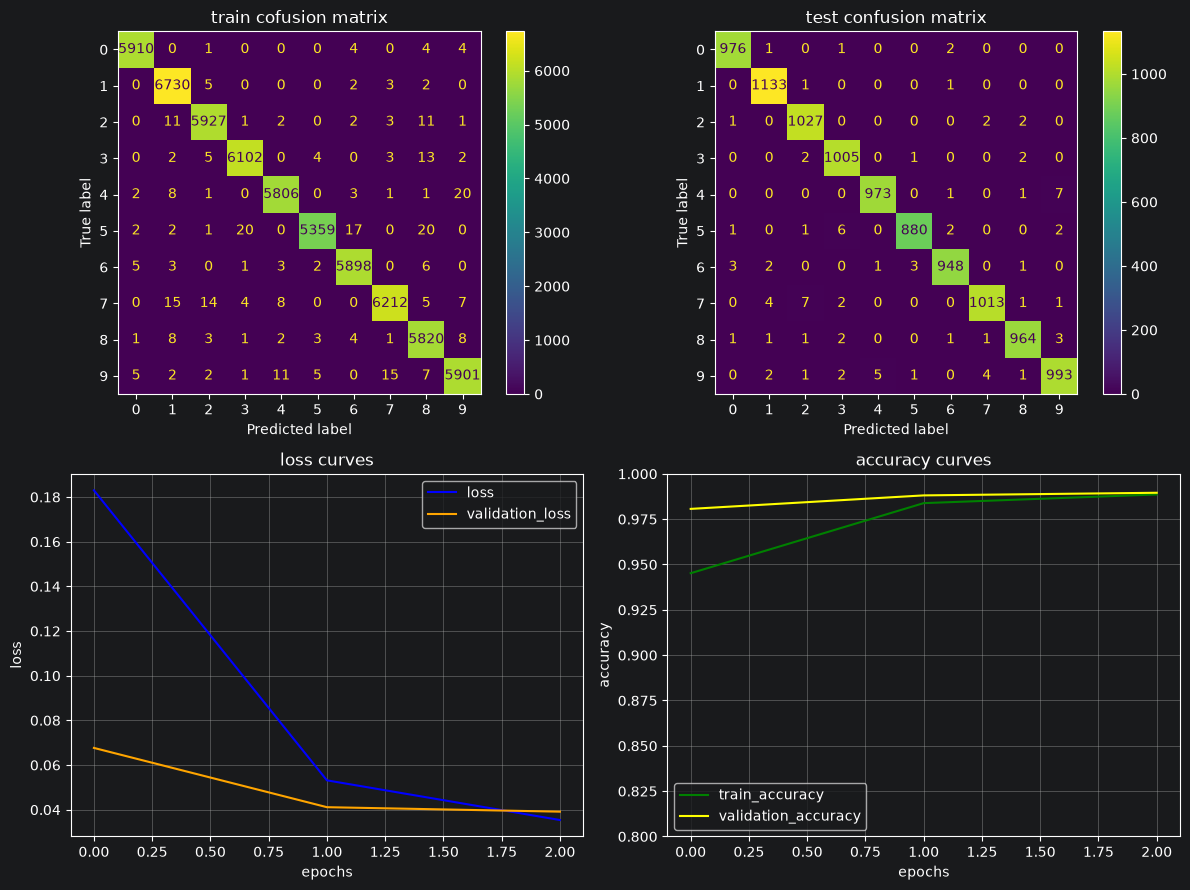

In [11]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(64, (5, 5), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

met5, mod5, cm_tr5, cm_te5, pred_te5, h5 = entrenar_evaluar(
    model,
    x_tr=x_train,
    y_tr=y_train,
    x_te=x_test,
    y_te=y_test,
    epochs=3
)

metricas = pd.concat([metricas, pd.DataFrame([met5])], ignore_index=True)
display(metricas)
resumen(cm_tr5, cm_te5, h5)

Alcanzamos un 99.12% de accuracy y redujimos los fallos a solo 88 errores en el conjunto de test. La combinación de un kernel inicial más amplio 5x5, una más fina de 3x3 y la regularización suave con Dropout (0.2) funcionaron tal como se esperaba, superando ampliamente al baseline inicial (que tenía 171 errores) y consolidándose como la mejor arquitectura de todos los experimentos.

In [ ]:
mod5.save("mejor_modelo_p3.keras")